# Import libraries

In [ ]:
!pip install scipy

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy.interpolate import interp1d
from glob import glob

# Load data

In [62]:
user_local_dir = "/home/maxence/dev/hardware/tms_validation" # Change this to your local directory

# Data directory
data_folder_dir = os.path.join(user_local_dir, "20260217_TMS_Voltage_Pulse")
data_file_paths = [os.path.join(data_folder_dir, f"SDS0000{i}.CSV") for i in range(2, 10)] + [os.path.join(data_folder_dir, f"SDS000{i}.CSV") for i in range(10, 17)]
print(f"Data file paths: {data_file_paths}")

# Output directory
output_folder_dir = os.path.join(user_local_dir, "20260217_TMS_Voltage_Pulse/Output")
os.makedirs(output_folder_dir, exist_ok=True)
print(f"Output folder directory: {output_folder_dir}")

Data file paths: ['/home/maxence/dev/hardware/tms_validation/20260217_TMS_Voltage_Pulse/SDS00002.CSV', '/home/maxence/dev/hardware/tms_validation/20260217_TMS_Voltage_Pulse/SDS00003.CSV', '/home/maxence/dev/hardware/tms_validation/20260217_TMS_Voltage_Pulse/SDS00004.CSV', '/home/maxence/dev/hardware/tms_validation/20260217_TMS_Voltage_Pulse/SDS00005.CSV', '/home/maxence/dev/hardware/tms_validation/20260217_TMS_Voltage_Pulse/SDS00006.CSV', '/home/maxence/dev/hardware/tms_validation/20260217_TMS_Voltage_Pulse/SDS00007.CSV', '/home/maxence/dev/hardware/tms_validation/20260217_TMS_Voltage_Pulse/SDS00008.CSV', '/home/maxence/dev/hardware/tms_validation/20260217_TMS_Voltage_Pulse/SDS00009.CSV', '/home/maxence/dev/hardware/tms_validation/20260217_TMS_Voltage_Pulse/SDS00010.CSV', '/home/maxence/dev/hardware/tms_validation/20260217_TMS_Voltage_Pulse/SDS00011.CSV', '/home/maxence/dev/hardware/tms_validation/20260217_TMS_Voltage_Pulse/SDS00012.CSV', '/home/maxence/dev/hardware/tms_validation/2026

In [63]:
data_csv = [pd.read_csv(data_file_dir) for data_file_dir in data_file_paths]
print(len(data_csv))
data_csv[0].head() 

15


,Record Length,10000,Source,CH1
0,Sample Interval,CH1:0.0000000800000,Second,Volt
1,Vertical Units,CH1:V,-0.000372,0
2,Vertical Scale,CH1:0.10,-0.00037192,0
3,Vertical Offset,CH1:0.00,-0.00037184,0
4,Horizontal Units,s,-0.00037176,0


In [64]:
data = []
for data_csv_i in data_csv:
    data_i = data_csv_i.loc[data_csv_i.index[1]:, ["Source", "CH1"]].astype(float).copy()
    data_i.columns = ["Time [s]", "Voltage [V]"] # Rename columns
    data_i = data_i.reset_index(drop=True) # Reset indices
    data.append(data_i)
print(len(data))
data[0].head()

15


,Time [s],Voltage [V]
0,-0.000372,0.000
1,-0.000372,0.000
2,-0.000372,0.000
3,-0.000372,0.000
4,-0.000372,-0.008


# Plot Voltage Measured by Rx Coil

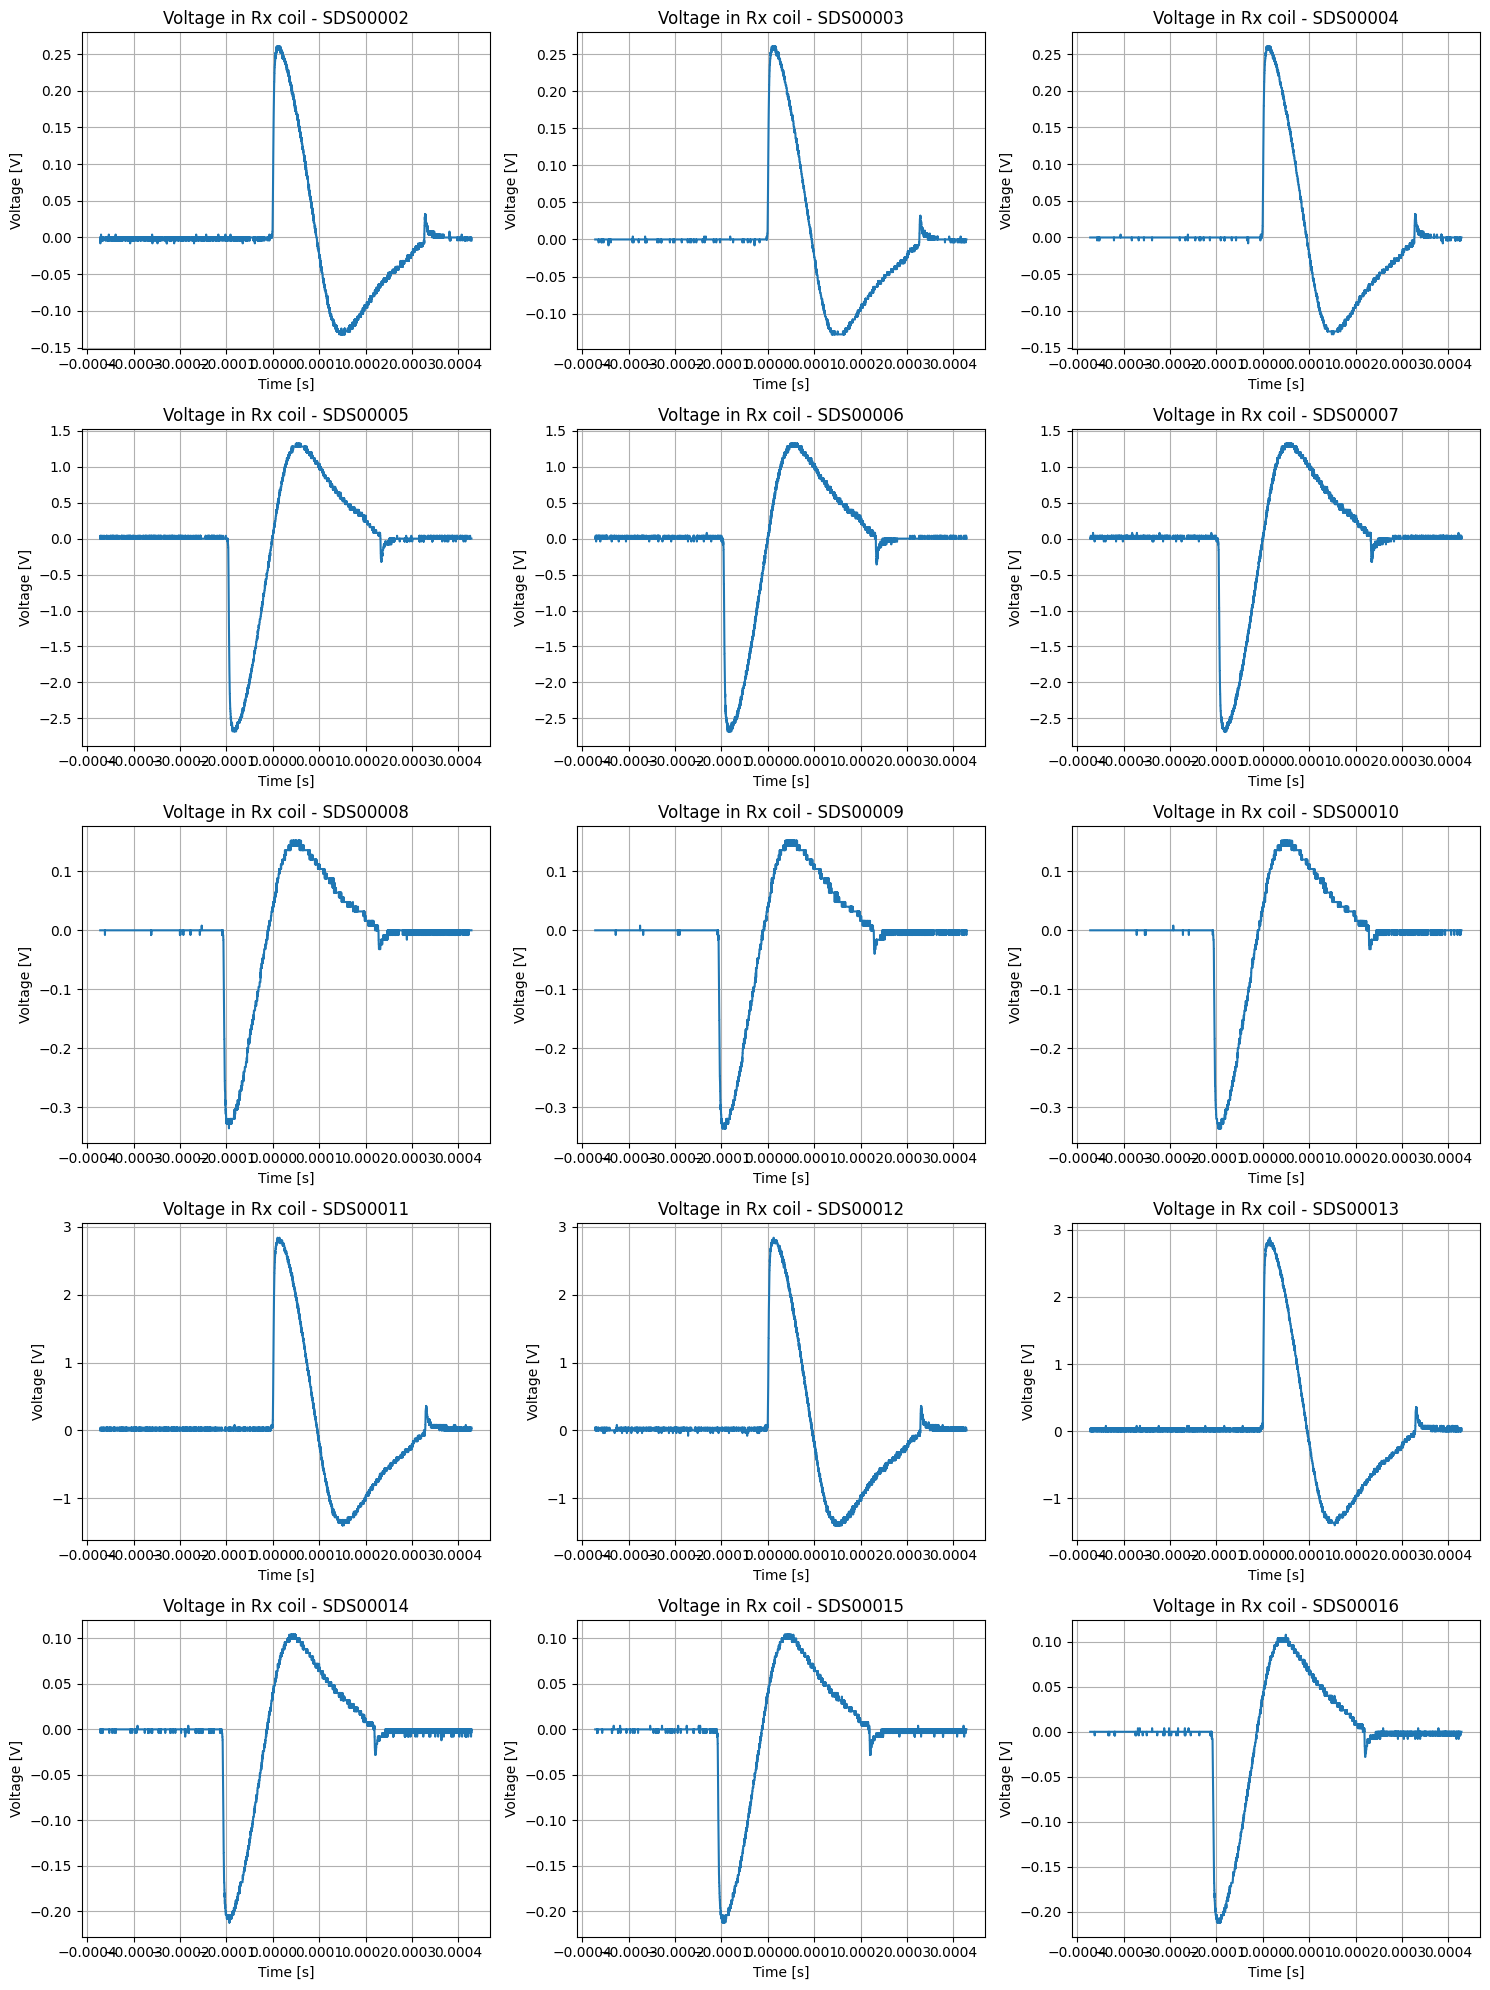

In [155]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 20))

axes = axes.flatten()  # Flatten the 2D array of axes to 1D for easy iteration
for i, data_i in enumerate(data):
    axes[i].plot(data_i["Time [s]"], data_i["Voltage [V]"])
    axes[i].set_xlabel("Time [s]")
    axes[i].set_ylabel("Voltage [V]")
    axes[i].set_title(f"Voltage in Rx coil - {data_file_paths[i].split('/')[-1][:-4]}")  # Extract file name without extension for title
    axes[i].grid()

plt.tight_layout()
plt.savefig(os.path.join(output_folder_dir, f"{data_file_paths[0].split('/')[-1][:-4]}_RxCoil_voltage_all.png"),
            dpi=300,              # high resolution
            bbox_inches='tight')  # removes extra white space
plt.show()
plt.close()

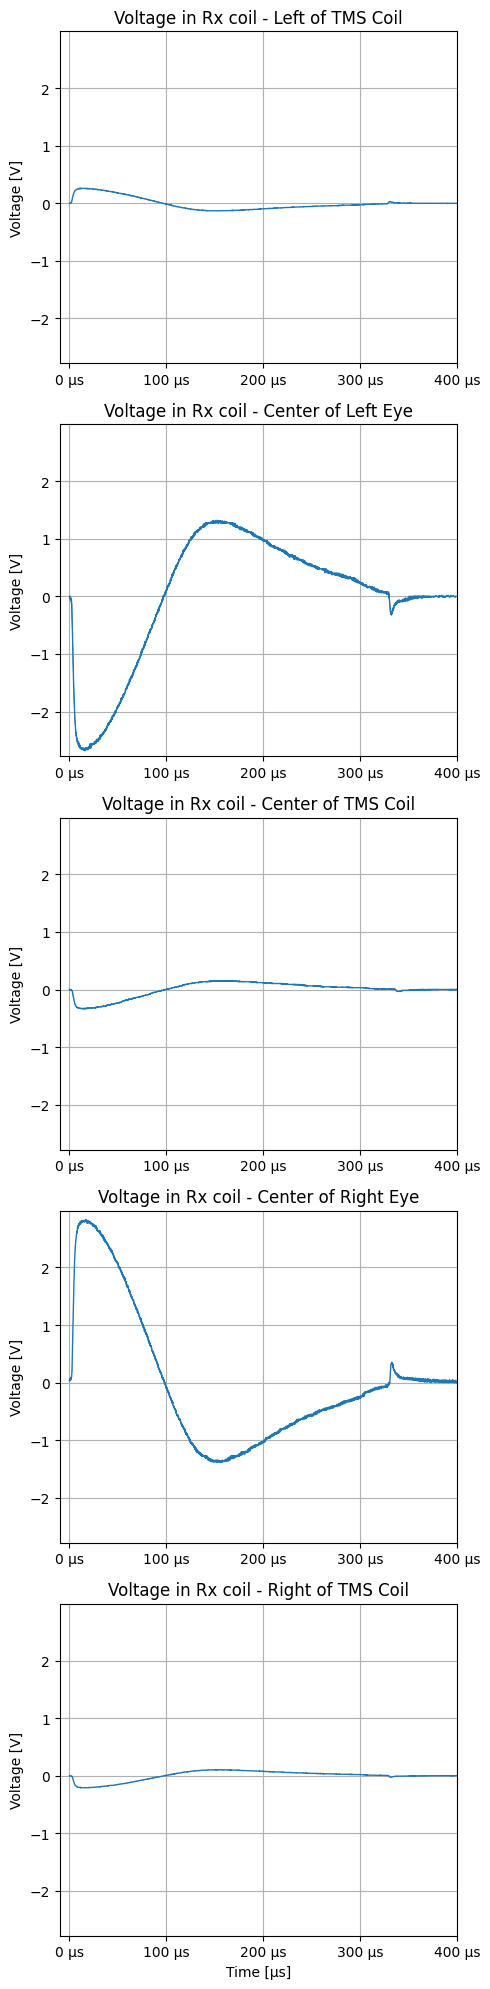

In [246]:

pulse_starts = [
    -25e-7, -9.8e-5, -10.9e-5, -2.5e-6, -11.1e-5
]
pulse_length = 400e-6 # 400 microseconds


# same but average + sd of each row
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(5, 20))

position_labels = ["Left of TMS Coil", "Center of Left Eye", "Center of TMS Coil", "Center of Right Eye", "Right of TMS Coil"]

share_y = True  # Share y-axis across all subplots

average_pulses = []
std_pulses = []
for row_i, ax in enumerate(axes):
    pulses = data[row_i*3:(row_i+1)*3]  # Get the 3 pulses for the current row
    # Calculate mean and standard deviation across the 3 pulses
    mean_voltage = pd.concat(pulses).groupby("Time [s]")["Voltage [V]"].mean()
    std_voltage = pd.concat(pulses).groupby("Time [s]")["Voltage [V]"].std()
    time = mean_voltage.index

    # crop data to pulse
    mask = (time >= pulse_starts[row_i]) & (time <= pulse_starts[row_i] + pulse_length)
    time = time[mask]
    # set time to 0 at first index
    time = time - time[0]
    mean_voltage = mean_voltage[mask]
    std_voltage = std_voltage[mask]

    average_pulses.append(mean_voltage)
    std_pulses.append(std_voltage)
    
    axes[row_i].plot(time, mean_voltage, label="Mean Voltage", color='C0', linewidth=1)
    axes[row_i].fill_between(time, mean_voltage - std_voltage, mean_voltage + std_voltage, alpha=1, label="Std Deviation")
    axes[row_i].set_ylabel("Voltage [V]")
    axes[row_i].set_title(f"Voltage in Rx coil - {position_labels[row_i]}")  # Use position label for title
    axes[row_i].grid()

    axes[row_i].set_xlim(0-10e-6, pulse_length)  # Set x-axis limits to the pulse length

    # set x ticks every 100 microseconds
    axes[row_i].set_xticks([i * 1e-6 for i in range(0, int(pulse_length*1e6)+100, 100)])
    axes[row_i].set_xticklabels([f"{i} µs" for i in range(0, int(pulse_length*1e6)+100, 100)])


if share_y:
    min_voltage = min(mean.min() - std.min() for mean, std in zip(average_pulses, std_pulses))
    max_voltage = max(mean.max() + std.max() for mean, std in zip(average_pulses, std_pulses))
    for ax in axes.flatten():
        ax.set_ylim(min_voltage-0.1, max_voltage+0.1)


axes[-1].set_xlabel("Time [µs]")  # Set x-axis label for the last subplot

plt.tight_layout()
plt.savefig(os.path.join(output_folder_dir, f"{data_file_paths[0].split('/')[-1][:-4]}_RxCoil_voltage_all_samey.svg"))
plt.show()
plt.close()

# From Rx get the db/dt

In [150]:
# We used the WR483265-15F5-G Rx coil
outer_area = 48.2 * 32.2 # mm^2
inner_area = 34 * 18 # mm^2
average_area = (outer_area + inner_area) / 2 * 1e-6 # convert to m^2
print(f"Average area of Rx coil: {average_area} m^2")

N_turns = 15

NAeff = N_turns * average_area
print(f"N*A_eff of Rx coil: {NAeff} m^2")

Average area of Rx coil: 0.00108202 m^2
N*A_eff of Rx coil: 0.0162303 m^2


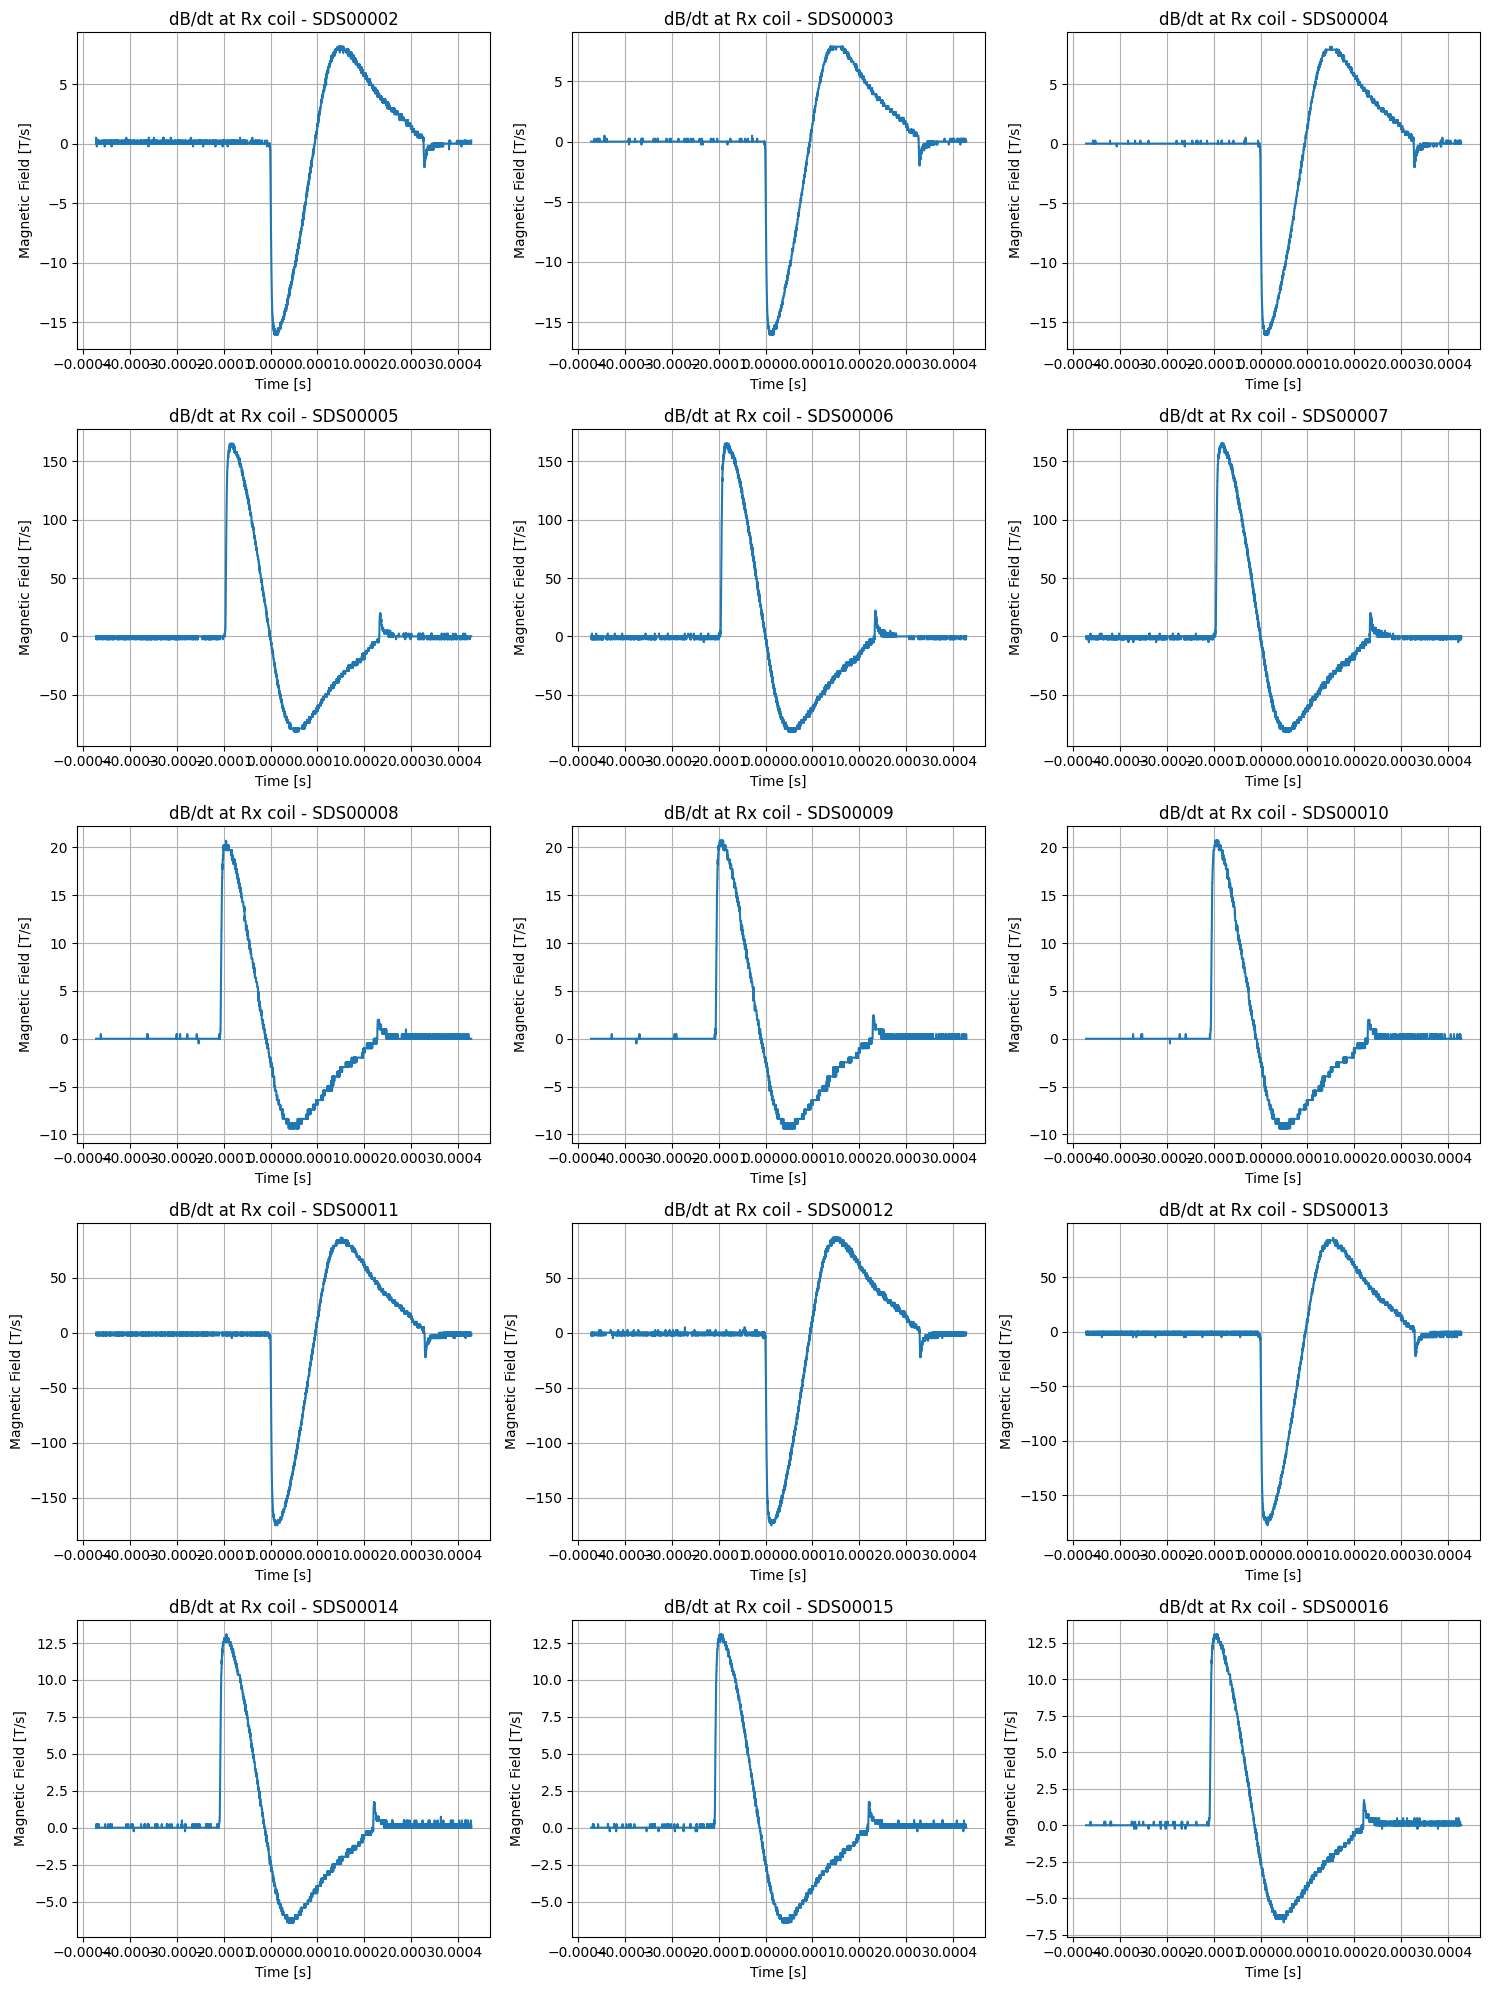

In [154]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 20))

axes = axes.flatten()  # Flatten the 2D array of axes to 1D for easy iteration
for i, data_i in enumerate(data):
    axes[i].plot(data_i["Time [s]"], -data_i["Voltage [V]"] / NAeff)  # Convert voltage to magnetic field using dB/dt = -V / (N * A_eff)
    axes[i].set_xlabel("Time [s]")
    axes[i].set_ylabel("Magnetic Field [T/s]")
    axes[i].set_title(f"dB/dt at Rx coil - {data_file_paths[i].split('/')[-1][:-4]}")  # Extract file name without extension for title
    axes[i].grid()

plt.tight_layout()
plt.savefig(os.path.join(output_folder_dir, f"{data_file_paths[0].split('/')[-1][:-4]}_RxCoil_db_dt_all.png"),
            dpi=300,              # high resolution
            bbox_inches='tight')  # removes extra white space
plt.show()
plt.close()

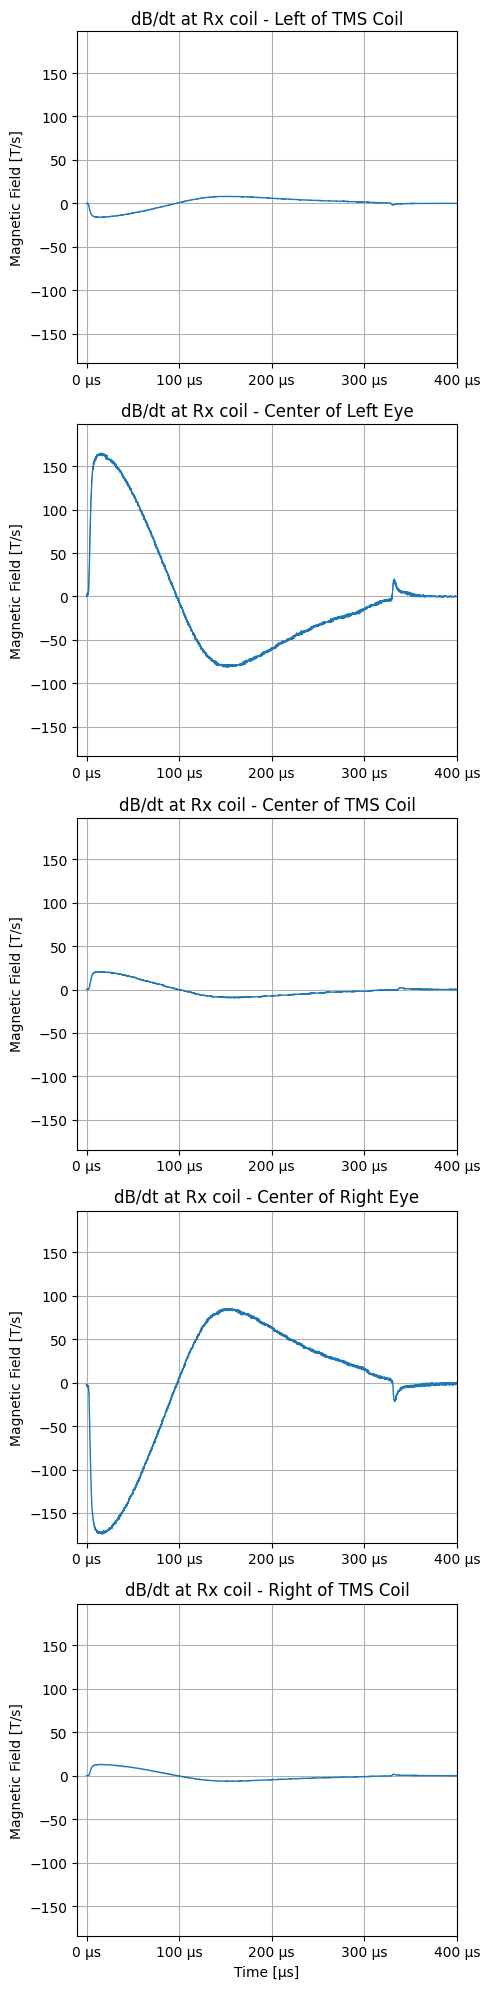

In [ ]:

pulse_starts = [
    -25e-7, -9.8e-5, -10.9e-5, -2.5e-6, -11.1e-5
]
pulse_length = 400e-6 # 400 microseconds


# same but average + sd of each row
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(5, 20))

position_labels = ["Left of TMS Coil", "Center of Left Eye", "Center of TMS Coil", "Center of Right Eye", "Right of TMS Coil"]

share_y = True  # Share y-axis across all subplots

average_pulses_dbdt = []
std_pulses_dbdt = []
for row_i, ax in enumerate(axes):
    pulses = data[row_i*3:(row_i+1)*3]  # Get the 3 pulses for the current row
    # Calculate mean and standard deviation across the 3 pulses
    mean_voltage = pd.concat(pulses).groupby("Time [s]")["Voltage [V]"].mean()
    std_voltage = pd.concat(pulses).groupby("Time [s]")["Voltage [V]"].std()
    time = mean_voltage.index

    # crop data to pulse
    mask = (time >= pulse_starts[row_i]) & (time <= pulse_starts[row_i] + pulse_length)
    time = time[mask]
    # set time to 0 at first index
    time = time - time[0]
    mean_voltage = mean_voltage[mask]
    std_voltage = std_voltage[mask]

    mean_dbdt = -mean_voltage / NAeff
    std_dbdt = std_voltage / NAeff

    average_pulses_dbdt.append(mean_dbdt)
    std_pulses_dbdt.append(std_dbdt)
    
    axes[row_i].plot(time, mean_dbdt, label="Mean dB/dt", color='C0', linewidth=1)
    axes[row_i].fill_between(time, mean_dbdt - std_dbdt, mean_dbdt + std_dbdt, alpha=1, label="Std Deviation")
    axes[row_i].set_ylabel("Magnetic Field [T/s]")
    axes[row_i].set_title(f"dB/dt at Rx coil - {position_labels[row_i]}")  # Use position label for title
    axes[row_i].grid()

    axes[row_i].set_xlim(0-10e-6, pulse_length)  # Set x-axis limits to the pulse length

    # set x ticks every 100 microseconds
    axes[row_i].set_xticks([i * 1e-6 for i in range(0, int(pulse_length*1e6)+100, 100)])
    axes[row_i].set_xticklabels([f"{i} µs" for i in range(0, int(pulse_length*1e6)+100, 100)])


if share_y:
    min_voltage = min(mean.min() - std.min() for mean, std in zip(average_pulses_dbdt, std_pulses_dbdt))
    max_voltage = max(mean.max() + std.max() for mean, std in zip(average_pulses_dbdt, std_pulses_dbdt))
    for ax in axes.flatten():
        ax.set_ylim(min_voltage-10, max_voltage+10)


axes[-1].set_xlabel("Time [µs]")  # Set x-axis label for the last subplot

plt.tight_layout()
plt.savefig(os.path.join(output_folder_dir, f"{data_file_paths[0].split('/')[-1][:-4]}_RxCoil_db_dt_all_samey.svg"))
plt.show()
plt.close()

In [ ]:
average_pulses_dbdt[1]

Time [s]
-0.000109   -0.000000
-0.000109    0.164302
-0.000109   -0.000000
-0.000109   -0.000000
-0.000109    0.164302
               ...   
 0.000291   -0.000000
 0.000291   -0.000000
 0.000291   -0.000000
 0.000291    0.164302
 0.000291   -0.000000
Name: Voltage [V], Length: 5000, dtype: float64

In [177]:
# Get total B field by integrating db/dt
# Assuming the pulse starts at time 0 and the signal is pure sine until first 0 crossing

pulse_db_dt = average_pulses_dbdt[1]
print(pulse_db_dt)

pulse_start = 0
pulse_zero_crossing = pulse_db_dt.index[np.where(pulse_db_dt <= 0)[0][0]]  # Find the first index where db/dt crosses zero
print(f"Pulse zero crossing time: {pulse_zero_crossing} s")

Time [s]
-0.000098   -0.000000
-0.000098   -0.000000
-0.000098   -0.000000
-0.000098   -0.000000
-0.000098    0.821509
               ...   
 0.000302   -0.000000
 0.000302   -0.000000
 0.000302   -0.000000
 0.000302   -0.000000
 0.000302   -0.000000
Name: Voltage [V], Length: 5001, dtype: float64
Pulse zero crossing time: -9.8e-05 s


# max db/dt heatmap 

In [189]:
max_db_dt = [np.array(pulse_db_dt.values)[np.argmax(np.abs(pulse_db_dt.values))] for pulse_db_dt in average_pulses_dbdt]
max_db_dt

[np.float64(-16.01942046665804),
 np.float64(165.12325711785982),
 np.float64(20.70202029537347),
 np.float64(-174.1598532785387),
 np.float64(12.979838121702413)]

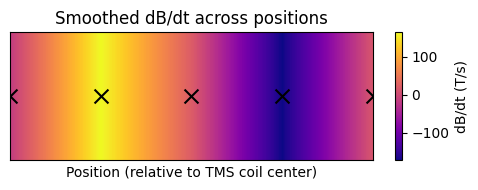

In [244]:
# Define upsampling factor
upsample_factor = 100
original_data = np.array(max_db_dt)
x = np.arange(len(original_data))

# Create interpolation function
f = interp1d(x, original_data, kind='linear')

# Generate new x-coordinates and interpolate
x_new = np.linspace(0, len(original_data) - 1, len(original_data) * upsample_factor)
upsampled_data = f(x_new)

# Plot smoothed result
plt.figure(figsize=(5, 2))

im = plt.imshow(upsampled_data.reshape(1, -1), aspect='auto', cmap='plasma', interpolation='nearest')

plt.scatter(np.array([-2, -1, 0, 1, 2])*125 + 249.5, np.zeros_like(max_db_dt), color='black', marker="x", s=100, label='Original Data')
plt.title("Smoothed dB/dt across positions")
plt.xlabel("Position (relative to TMS coil center)")
plt.yticks([])
plt.xticks([])
plt.colorbar(im, label='dB/dt (T/s)')
plt.tight_layout()

plt.savefig(os.path.join(output_folder_dir, f"{data_file_paths[0].split('/')[-1][:-4]}_RxCoil_db_dt_smoothed.svg"))

plt.show()